In [78]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [79]:
img = cv.imread('sat_image_plaksha.jpg')
gsc = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gsc = gsc.astype(np.float64)

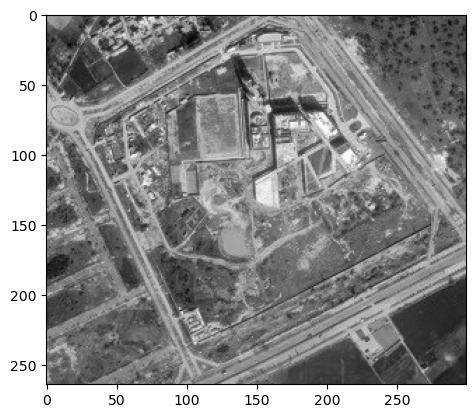

In [80]:
plt.imshow(gsc, cmap='gray')

In [81]:
for i in range(len(gsc.T)):
    gsc[:,i] = gsc[:,i] - gsc[:,i].mean()

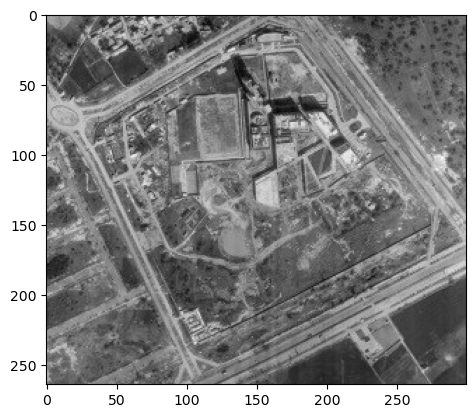

In [82]:
plt.imshow(gsc, cmap='gray')

In [83]:
cov = np.cov(gsc)

In [84]:
ev = np.linalg.eig(cov)

In [85]:
sorted = ev[0].argsort()[::-1]

In [86]:
ev_values = ev[0][sorted]
ev_vectors = ev[1][:,sorted]

In [87]:
Num_components = [10, 20, 30, 40, 50, 60, 91]

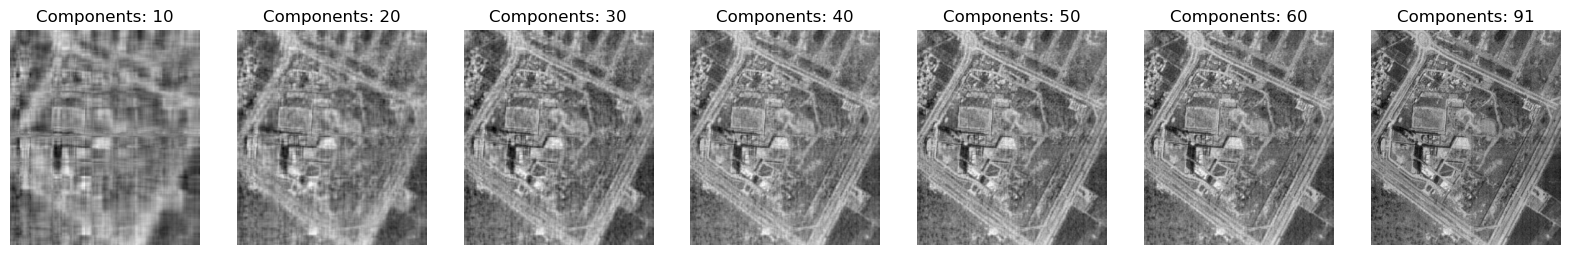

In [98]:
output_imgs = []

for i in Num_components:
    top_i = ev_vectors[:, :i]
    proj = np.dot(top_i.T, gsc).T
    im2 = np.dot(top_i, proj.T).T #mean is zero already
    output_imgs.append(im2)

plt.subplots(1, len(Num_components), figsize=(20,5))
for i in range(len(Num_components)):
    plt.subplot(1, len(Num_components), i+1)
    plt.imshow(output_imgs[i], cmap='gray')
    plt.title(f'Components: {Num_components[i]}')
    plt.axis('off')
plt.show()

In [105]:
from sklearn.decomposition import PCA
pca = PCA(n_components=91)
pca.fit(gsc.T)
pca.explained_variance_ratio_.sum()


np.float64(0.944348667924354)

### Q1: What is the difference between PCA and Feature Selection?

PCA creates a new space which has features that are a mixture of the features from the original space. Feature Selection just selects a subset of the original features without any transformation. The 91 features selected in the new space account for 95% of the variance in the original data. Many more features would be needed to achieve the same using feature selection.

### Q2: Why do we standardize features before applying PCA?

Standardizing features ensures that each feature contributes equally to the distance computations in PCA. If features are on different scales, those with larger scales can dominate the principal components, leading to biased results. Standardization centers the data around zero and scales it to have unit variance, allowing PCA to identify directions of maximum variance more effectively.

### Q3: What is the importance of Covariance Matrix in PCA?

The covariance matrix is used to find the relationships between different features in the dataset. We use its eigenvalues and eigenvectors to find the principal components. The chosen principal components are the directions in which the data varies the most, which are determined by the eigenvectors corresponding to the largest eigenvalues of the covariance matrix.

### Q4: What are some limitations of PCA?

- PCA assumes a linear relationship between features
- PCA loses information
- It is not clear which features contribute to each principal component

### Q5: How can we figure out the importance of individual PCs in PCA

The importance of each PC can be determined by checking its eigenvalue. The higher the eigenvalue, the more important the PC. We use this to get the eigenvectors that have a total of 95% of the eigenvalues and thus eigenvectors.